# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The SPECTRA Telecom Churn Dataset](https://www.kaggle.com/datasets/javierfalcondale/spectra-telecom-quantum-ready-churn-data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/javierfalcondale/spectra-telecom-quantum-ready-churn-data/spectra_telecom_churn.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('spectra_telecom_churn.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,...,age,customer_value,seconds_of_use_phase,frequency_of_use_phase,frequency_of_sms_phase,distinct_called_numbers_phase,customer_value_phase,in_pocket,target_real,target
0,8,0,38,0,4370,71,5,17,3,1,...,30,197.640,0.856732,0.699120,-1.62814,-0.577315,-0.351178,0,0,0
1,0,0,39,0,318,5,7,4,2,1,...,25,46.035,-2.681710,-2.730490,-1.13908,-2.518130,-2.444900,0,0,0
2,10,0,37,0,2453,60,359,24,3,1,...,30,1536.520,-0.565663,0.321297,2.84350,0.457118,2.767010,0,0,0
3,10,0,38,0,4198,66,1,35,1,1,...,15,240.020,0.778859,0.500704,-1.90907,1.662420,0.102865,0,0,0
4,3,0,38,0,2393,58,2,33,1,1,...,15,145.805,-0.658172,0.175815,-1.84149,1.558270,-1.116870,0,0,0


## last Five row

In [4]:
df.tail()

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,...,age,customer_value,seconds_of_use_phase,frequency_of_use_phase,frequency_of_sms_phase,distinct_called_numbers_phase,customer_value_phase,in_pocket,target_real,target
3145,21,0,19,2,6697,147,92,44,2,2,...,25,721.98,1.718270,2.374390,1.623230,2.434560,1.399050,1,0,0
3146,17,0,17,1,9237,177,80,42,5,1,...,55,261.21,2.300530,2.757880,1.499760,2.318170,0.371859,1,0,0
3147,13,0,18,4,3157,51,38,21,3,1,...,30,280.32,0.110323,-0.171953,0.880355,0.031687,0.485234,0,0,0
3148,7,0,11,2,4695,46,222,12,3,1,...,30,1077.64,1.025560,-0.369220,2.443820,-1.332710,2.348200,0,0,0
3149,8,1,11,2,1792,25,7,9,3,1,...,30,100.68,-1.222470,-1.726950,-1.471190,-1.742480,-1.733800,0,1,1


## Shape of our dataset

In [5]:
df.shape

(3150, 21)

## List out all columns

In [6]:
df.columns

Index(['call_failure', 'complains', 'subscription_length', 'charge_amount',
       'seconds_of_use', 'frequency_of_use', 'frequency_of_sms',
       'distinct_called_numbers', 'age_group', 'tariff_plan', 'status', 'age',
       'customer_value', 'seconds_of_use_phase', 'frequency_of_use_phase',
       'frequency_of_sms_phase', 'distinct_called_numbers_phase',
       'customer_value_phase', 'in_pocket', 'target_real', 'target'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

call_failure                       int64
complains                          int64
subscription_length                int64
charge_amount                      int64
seconds_of_use                     int64
frequency_of_use                   int64
frequency_of_sms                   int64
distinct_called_numbers            int64
age_group                          int64
tariff_plan                        int64
status                             int64
age                                int64
customer_value                   float64
seconds_of_use_phase             float64
frequency_of_use_phase           float64
frequency_of_sms_phase           float64
distinct_called_numbers_phase    float64
customer_value_phase             float64
in_pocket                          int64
target_real                        int64
target                             int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   call_failure                   3150 non-null   int64  
 1   complains                      3150 non-null   int64  
 2   subscription_length            3150 non-null   int64  
 3   charge_amount                  3150 non-null   int64  
 4   seconds_of_use                 3150 non-null   int64  
 5   frequency_of_use               3150 non-null   int64  
 6   frequency_of_sms               3150 non-null   int64  
 7   distinct_called_numbers        3150 non-null   int64  
 8   age_group                      3150 non-null   int64  
 9   tariff_plan                    3150 non-null   int64  
 10  status                         3150 non-null   int64  
 11  age                            3150 non-null   int64  
 12  customer_value                 3150 non-null   f

## Check Null Value

In [9]:
df.isnull().sum()

call_failure                     0
complains                        0
subscription_length              0
charge_amount                    0
seconds_of_use                   0
frequency_of_use                 0
frequency_of_sms                 0
distinct_called_numbers          0
age_group                        0
tariff_plan                      0
status                           0
age                              0
customer_value                   0
seconds_of_use_phase             0
frequency_of_use_phase           0
frequency_of_sms_phase           0
distinct_called_numbers_phase    0
customer_value_phase             0
in_pocket                        0
target_real                      0
target                           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,age_group,tariff_plan,...,age,customer_value,seconds_of_use_phase,frequency_of_use_phase,frequency_of_sms_phase,distinct_called_numbers_phase,customer_value_phase,in_pocket,target_real,target
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,...,3150.000000,3150.00000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,...,30.998413,470.97289,-0.000214,0.000209,0.000456,-0.000279,-0.000651,0.180000,0.157143,0.242222
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,...,8.831095,517.01537,1.814349,1.814443,1.813888,1.812848,1.813810,0.384248,0.363993,0.428496
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,15.000000,0.00000,-3.141590,-3.141590,-3.141590,-3.141590,-3.141590,0.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,...,25.000000,113.80125,-1.575780,-1.567308,-1.569680,-1.569847,-1.559667,0.000000,0.000000,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,...,30.000000,228.48000,0.005142,0.004226,-0.000293,-0.003136,-0.002257,0.000000,0.000000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,...,30.000000,788.38875,1.580022,1.563417,1.566970,1.570310,1.570035,0.000000,0.000000,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,...,55.000000,2165.28000,3.141590,3.141590,3.141590,3.141590,3.141590,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

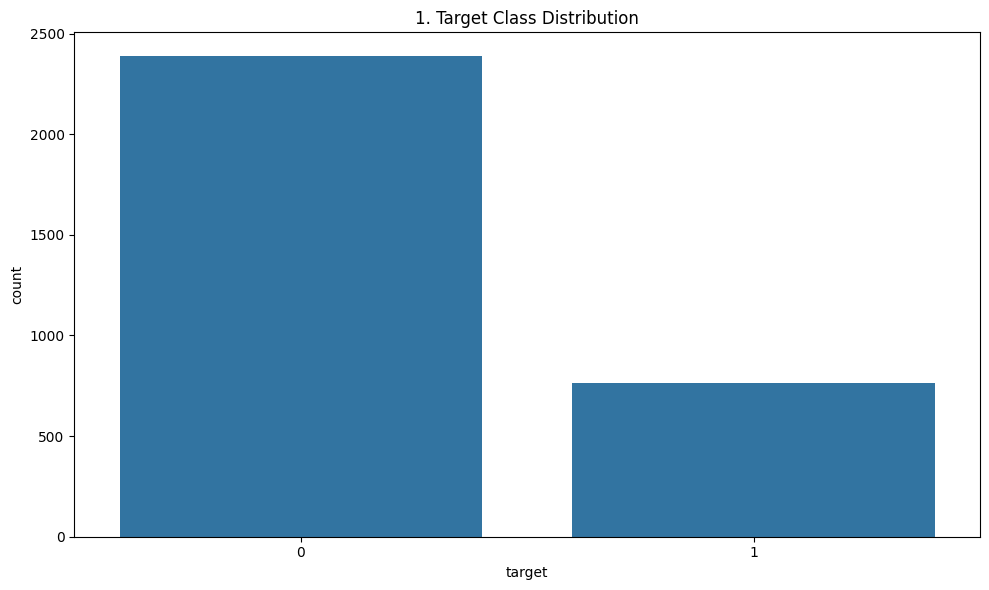

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='target', data=df)
plt.title(f'{plot_no}. Target Class Distribution')
show_fig()
plot_no += 1

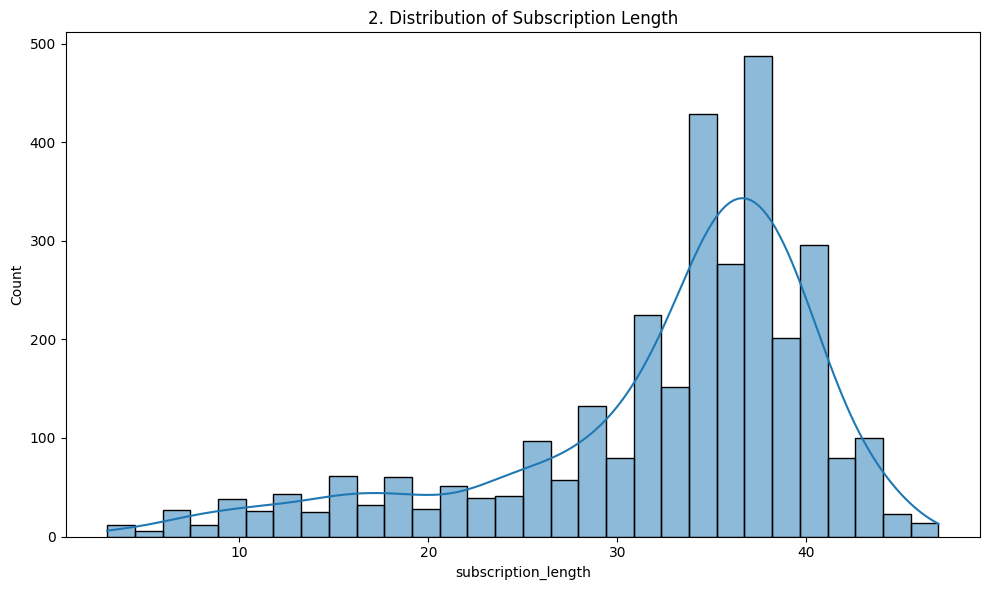

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['subscription_length'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Subscription Length')
show_fig()
plot_no += 1

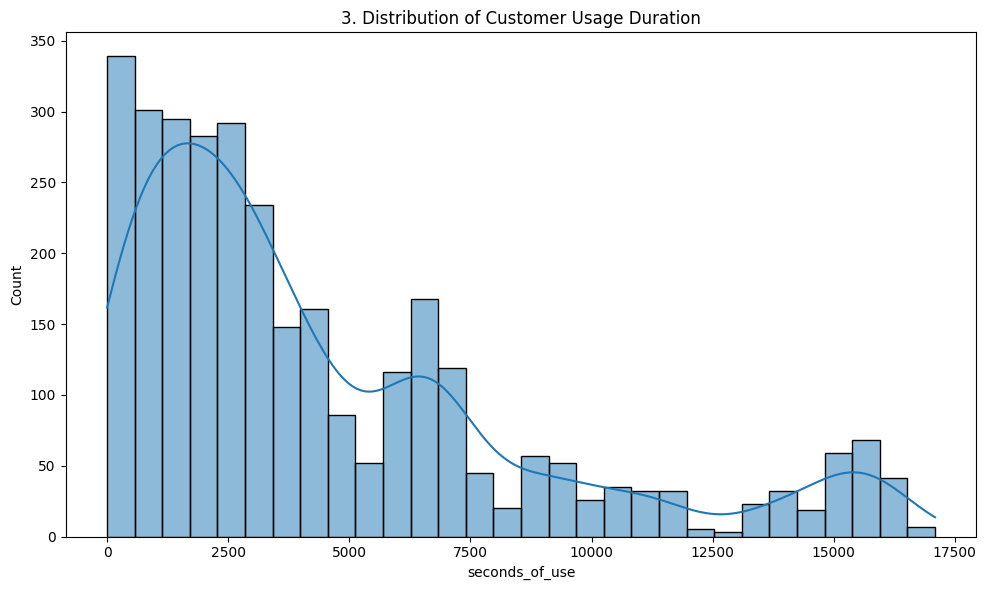

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['seconds_of_use'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Customer Usage Duration')
show_fig()
plot_no += 1

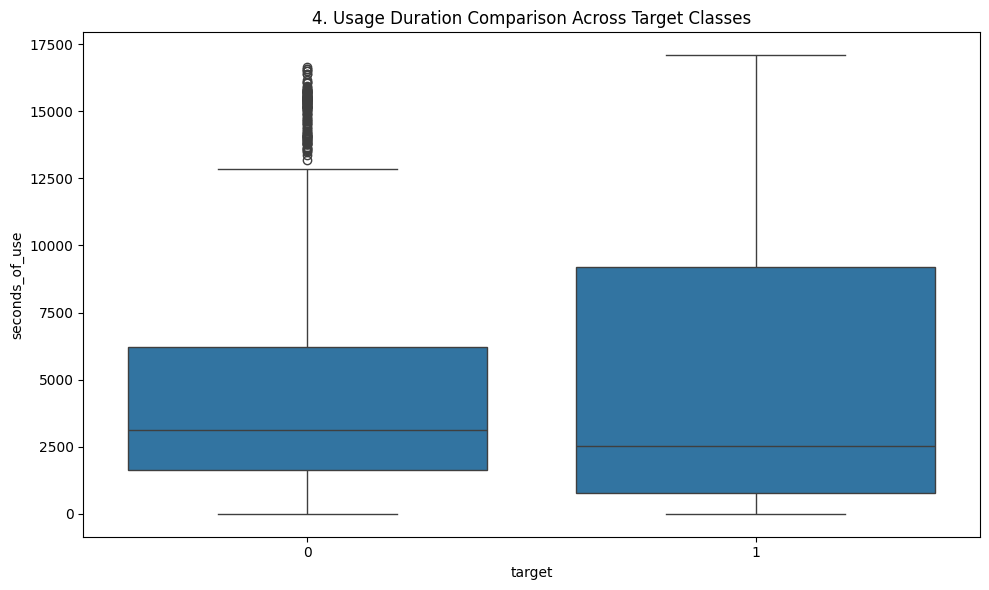

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='seconds_of_use', data=df)
plt.title(f'{plot_no}. Usage Duration Comparison Across Target Classes')
show_fig()
plot_no += 1

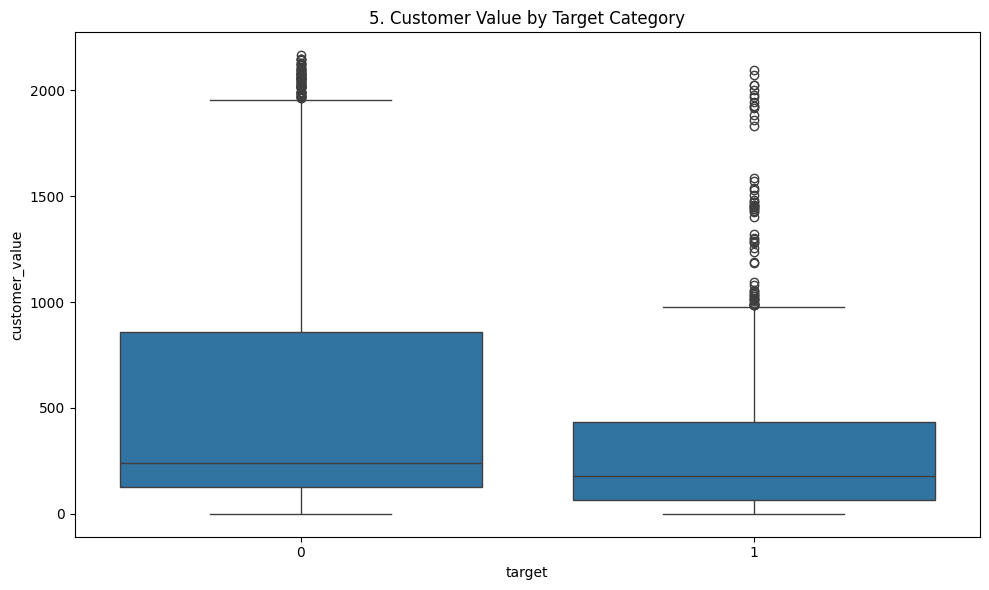

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='customer_value', data=df)
plt.title(f'{plot_no}. Customer Value by Target Category')
show_fig()
plot_no += 1

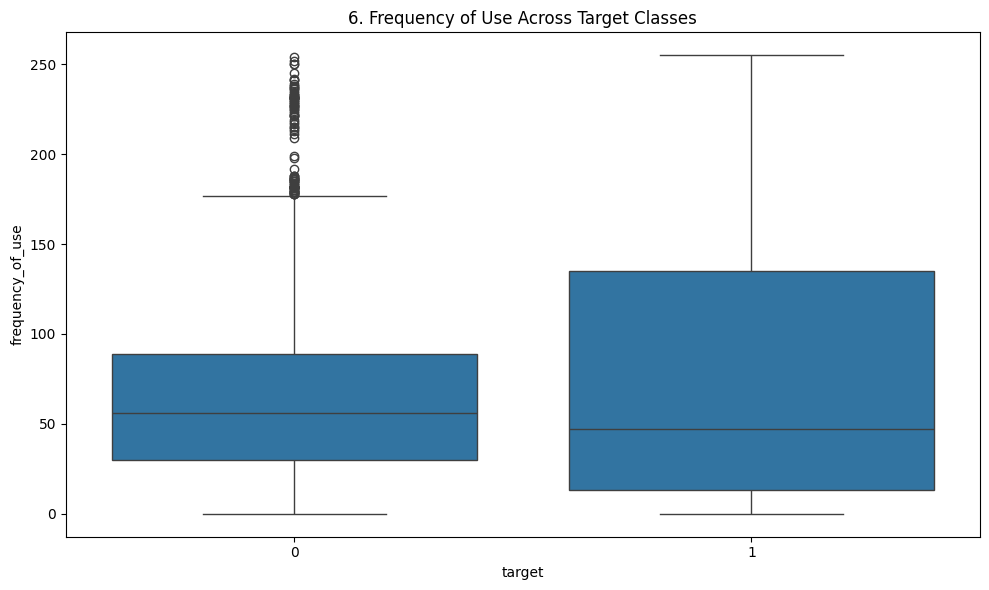

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='frequency_of_use', data=df)
plt.title(f'{plot_no}. Frequency of Use Across Target Classes')
show_fig()
plot_no += 1

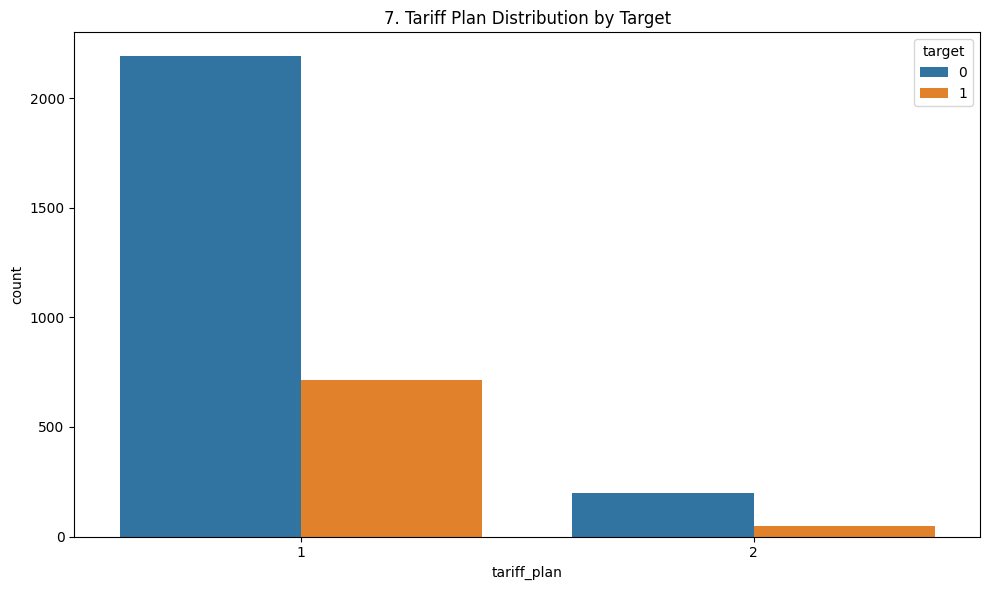

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='tariff_plan', hue='target', data=df)
plt.title(f'{plot_no}. Tariff Plan Distribution by Target')
show_fig()
plot_no += 1

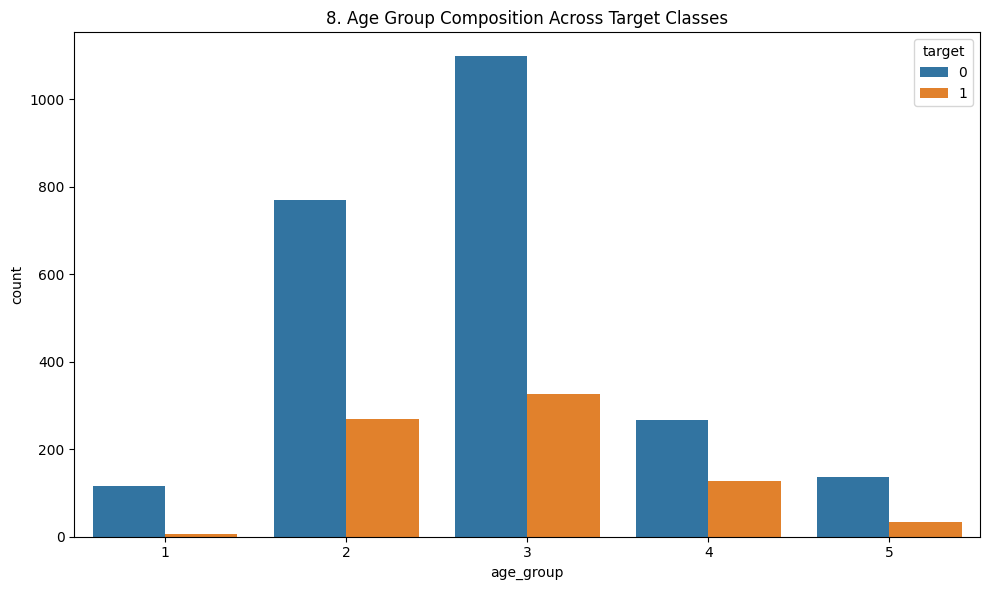

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='age_group', hue='target', data=df)
plt.title(f'{plot_no}. Age Group Composition Across Target Classes')
show_fig()
plot_no += 1

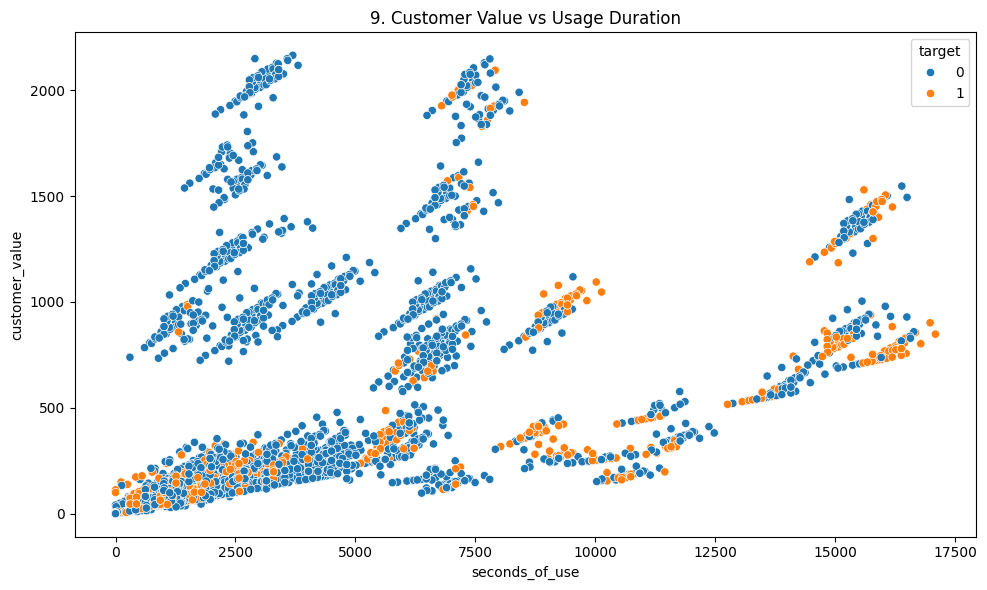

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='seconds_of_use', y='customer_value', hue='target', data=df)
plt.title(f'{plot_no}. Customer Value vs Usage Duration')
show_fig()
plot_no += 1

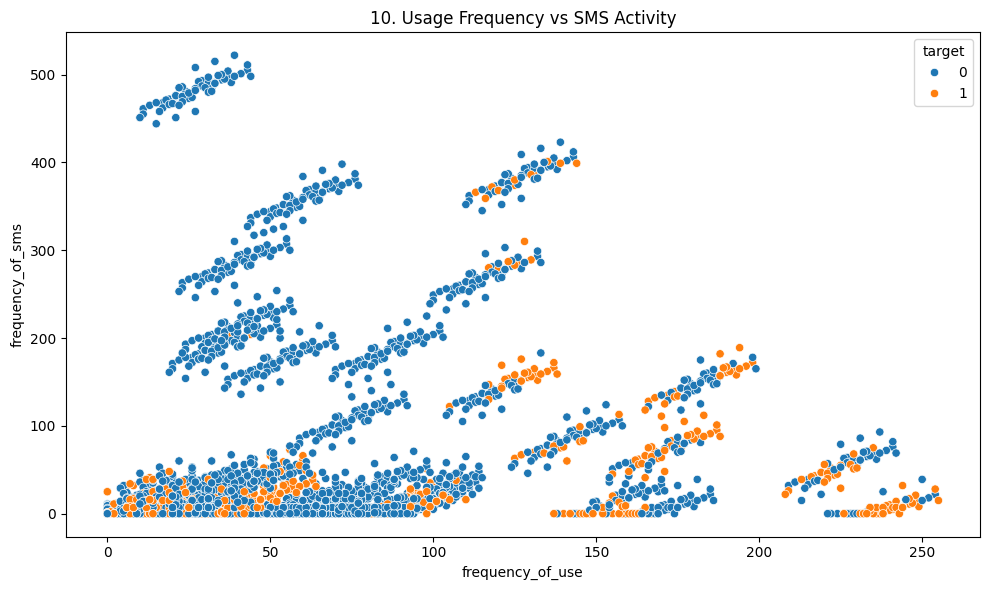

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='frequency_of_use', y='frequency_of_sms', hue='target', data=df)
plt.title(f'{plot_no}. Usage Frequency vs SMS Activity')
show_fig()
plot_no += 1

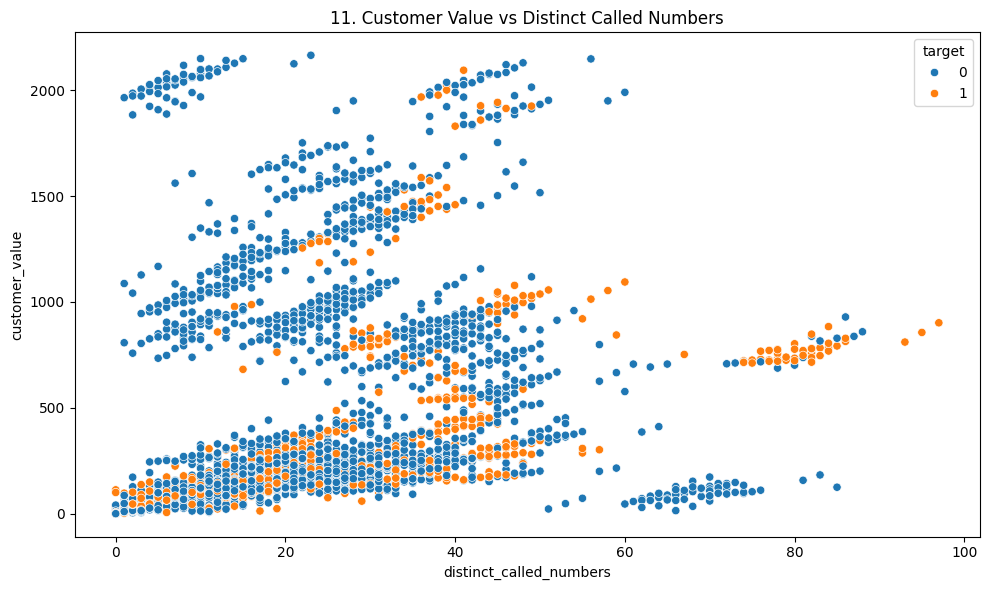

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='distinct_called_numbers', y='customer_value', hue='target', data=df)
plt.title(f'{plot_no}. Customer Value vs Distinct Called Numbers')
show_fig()
plot_no += 1

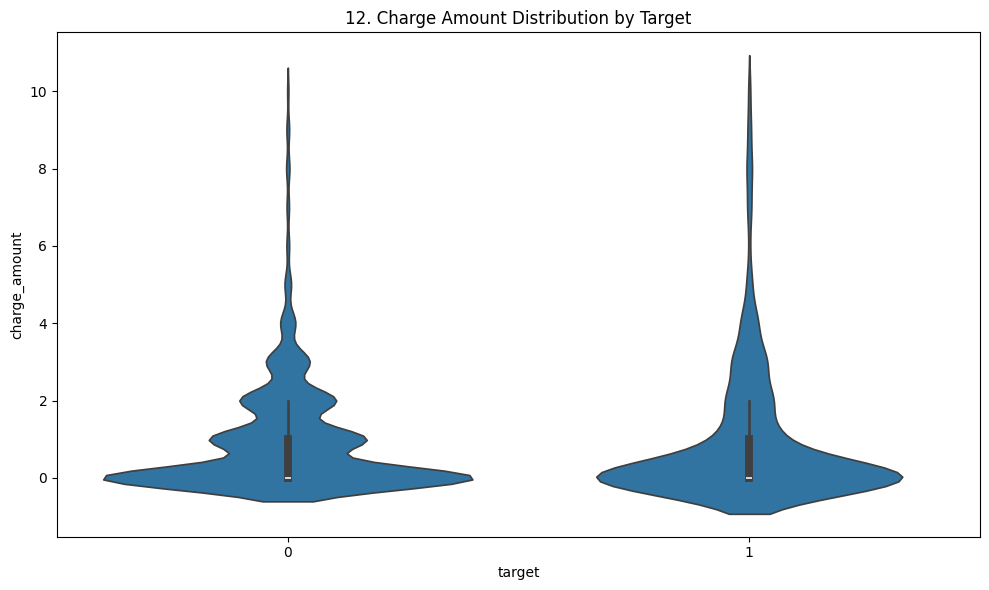

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='target', y='charge_amount', data=df)
plt.title(f'{plot_no}. Charge Amount Distribution by Target')
show_fig()
plot_no += 1

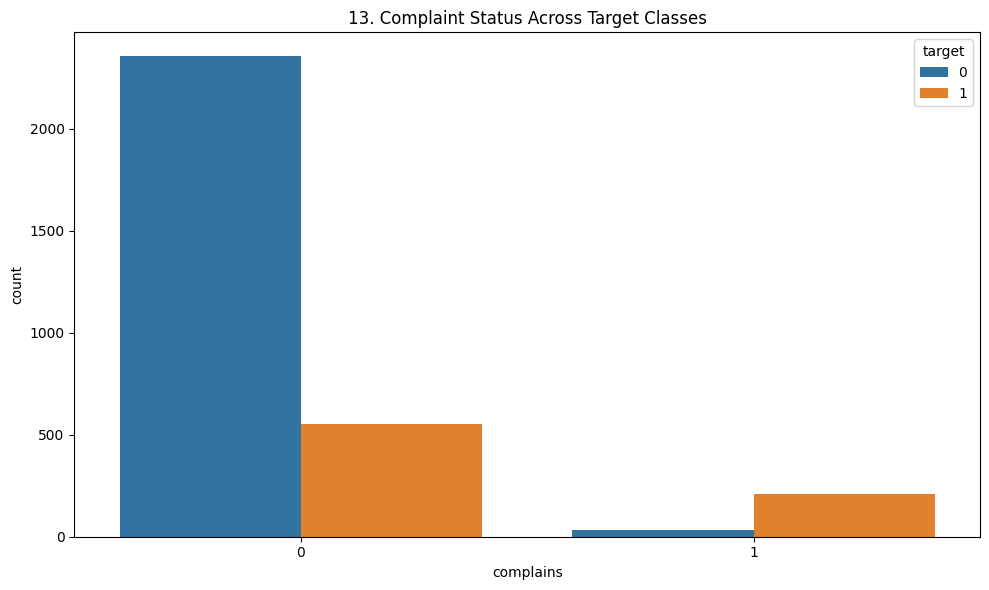

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='complains', hue='target', data=df)
plt.title(f'{plot_no}. Complaint Status Across Target Classes')
show_fig()
plot_no += 1

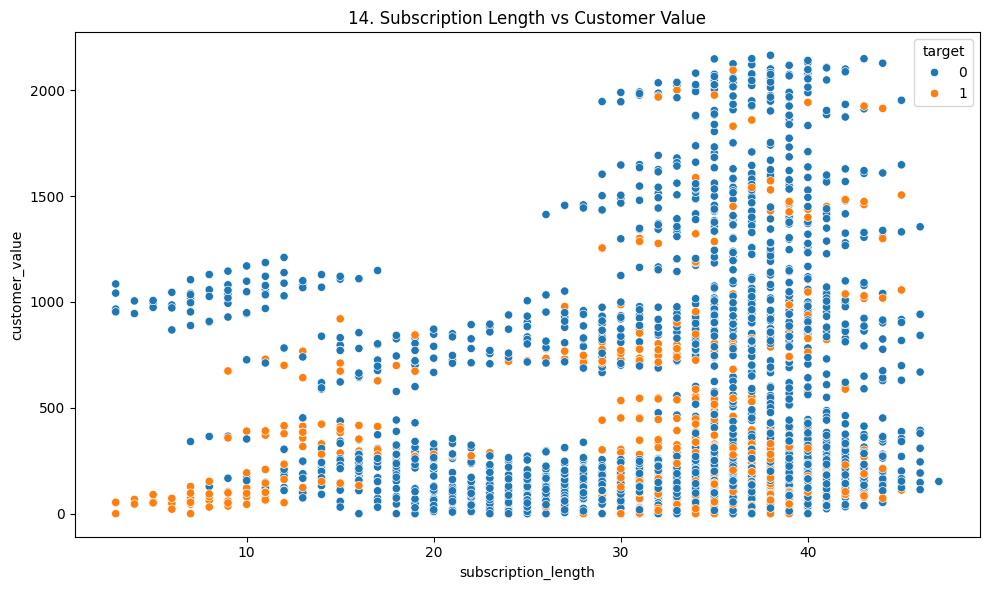

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='subscription_length', y='customer_value', hue='target', data=df)
plt.title(f'{plot_no}. Subscription Length vs Customer Value')
show_fig()
plot_no += 1

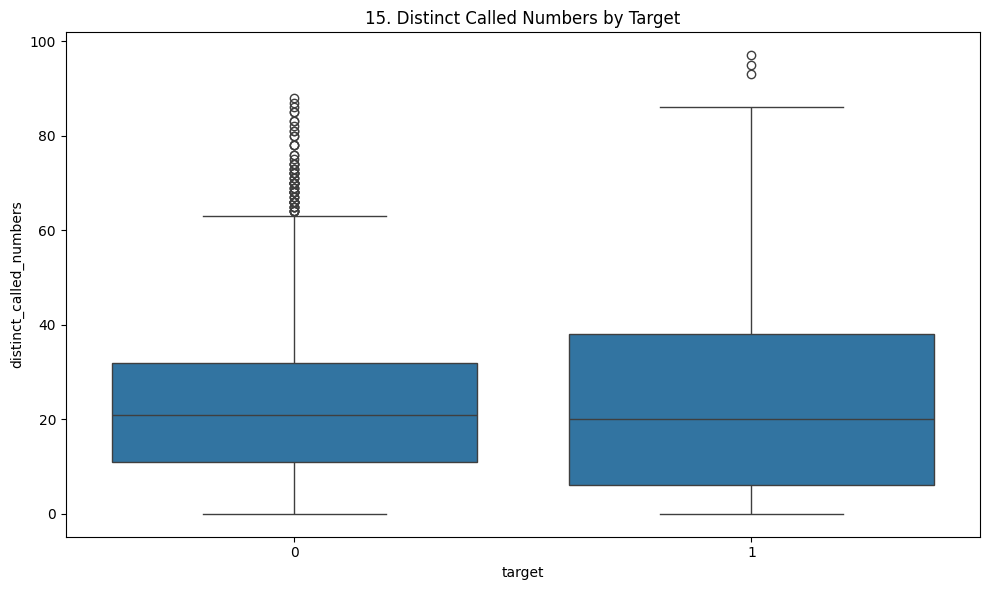

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='distinct_called_numbers', data=df)
plt.title(f'{plot_no}. Distinct Called Numbers by Target')
show_fig()
plot_no += 1

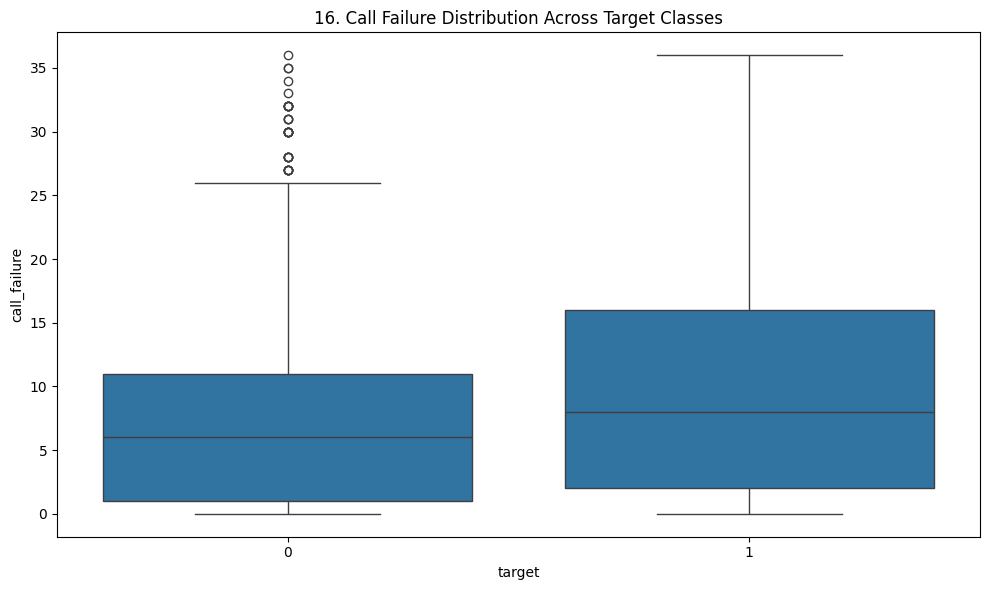

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='call_failure', data=df)
plt.title(f'{plot_no}. Call Failure Distribution Across Target Classes')
show_fig()
plot_no += 1

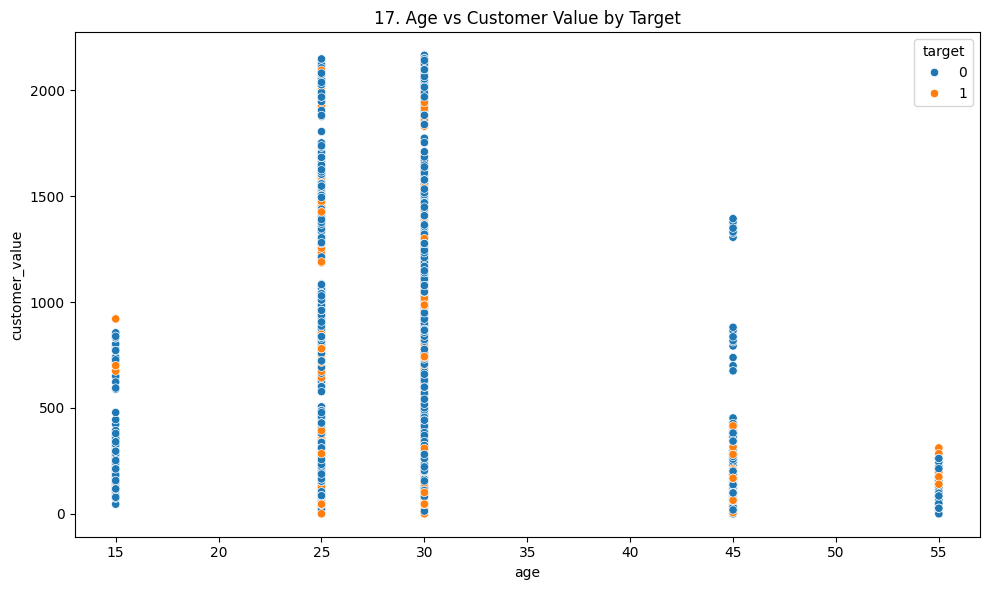

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='customer_value', hue='target', data=df)
plt.title(f'{plot_no}. Age vs Customer Value by Target')
show_fig()
plot_no += 1

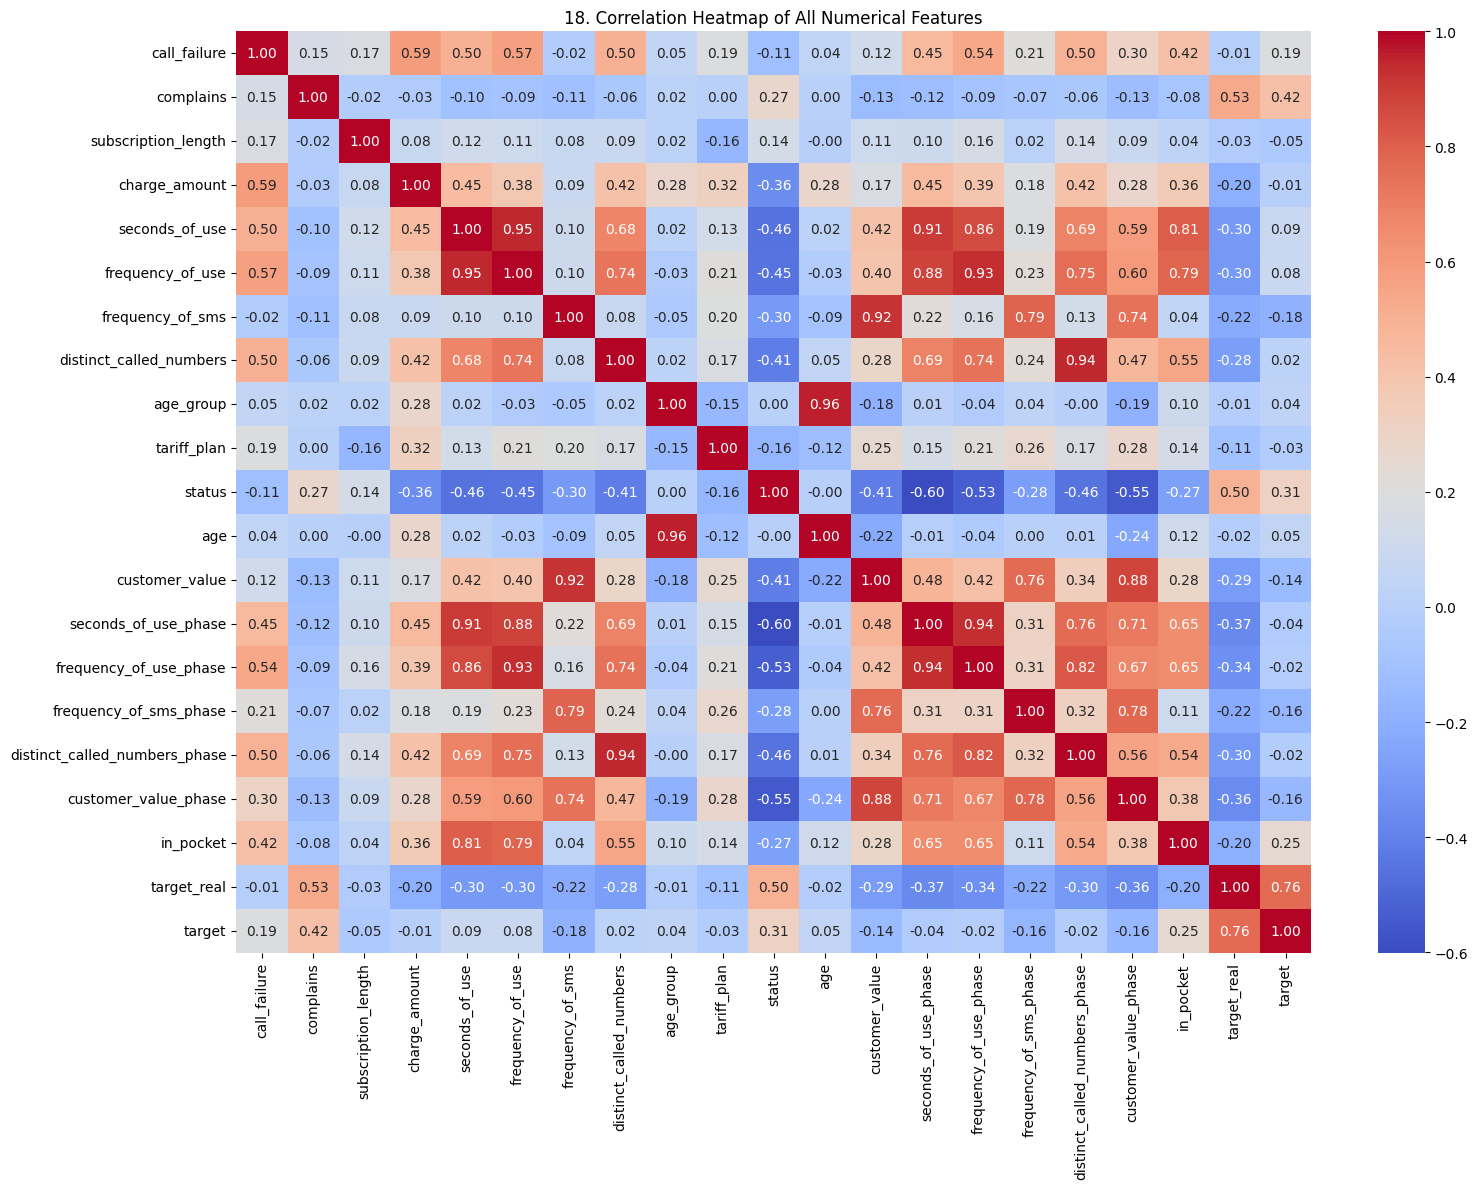

In [30]:
corr = df.corr(numeric_only=True)

fig = plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create feature matrix and target vector

In [31]:
X = df.drop(columns=['target'])
y = df['target']

## Split dataset into training and testing sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale numerical features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Support Vector Machine model

In [34]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train, y_train)

SVC(random_state=42)

## Predict on test data

In [35]:
y_pred = model.predict(X_test)

## Print model accuracy

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy Score: 0.9365 (93.65%)


## Display confusion matrix

<Figure size 700x600 with 0 Axes>

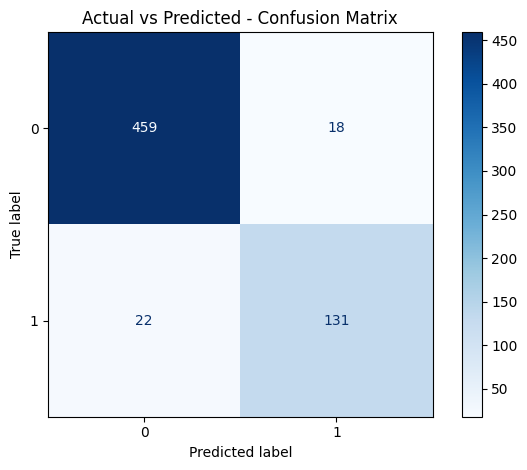

In [37]:
fig = plt.figure(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    values_format='d'
)
plt.title("Actual vs Predicted - Confusion Matrix")
plt.tight_layout()
plt.show()